# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Albert Sanggam Nalom Sinurat]
- **Email:** [asinurat052@gmail.com]
- **ID Dicoding:** [CDCC319D6Y0833]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1 :** Bagaimana pengaruh kondisi cuaca dan musim terhadap total penyewaan sepeda (casual dan registered) selama periode tahun 2011-2012?
- **Pertanyaan 2 :** Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari (0-23) jika dibandingkan antara hari kerja (workingday) dan hari libur/akhir pekan dalam keseluruhan periode observasi (2011-2012)?

## Import Semua Packages/Library yang Digunakan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set style untuk visualisasi (meningkatkan keterbacaan)
sns.set_theme(style="ticks", palette="pastel")
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [7]:
# Memuat data harian dan per jam dari Bike Sharing Dataset
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("Dimensi dataset day:", day_df.shape)
print("Dimensi dataset hour:", hour_df.shape)

Dimensi dataset day: (731, 16)
Dimensi dataset hour: (17379, 17)


**Insight Gathering Data :**
- Berhasil memuat data dari day.csv dan hour.csv.
- Sesuai dokumentasi, dataset hour.csv menyimpan rekap data per jam dengan total 17.379 baris.
- Dataset day.csv menyimpan rekap data harian dengan total 731 baris.

### Assessing Data

In [8]:
# Memeriksa tipe data dan missing value pada day_df
print("Info Day Dataset:\n")
day_df.info()
print("\nJumlah missing value (day):\n", day_df.isna().sum())
print("\nJumlah duplikasi (day):", day_df.duplicated().sum())

# Memeriksa tipe data dan missing value pada hour_df
print("\nInfo Hour Dataset:\n")
hour_df.info()
print("\nJumlah missing value (hour):\n", hour_df.isna().sum())
print("\nJumlah duplikasi (hour):", hour_df.duplicated().sum())

Info Day Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah missing value (day):
 instant       0
dteday        0
season      

**Insight Assessing Data:**
- Tidak ditemukan missing value (Null / NaN) pada kedua dataset.
- Tidak ditemukan data duplikat pada kedua dataset.
- Tipe data kolom dteday masih berupa object (string) dan perlu diubah menjadi datetime agar memudahkan analisis berbasis waktu.
- Beberapa kolom kategori seperti season, weathersit, weekday masih direpresentasikan dalam bentuk numerik yang kurang intuitif.

### Cleaning Data

In [9]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai numerik menjadi string/kategori agar mudah diinterpretasikan pada visualisasi
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}

# Menerapkan mapping
day_df['season_label'] = day_df['season'].map(season_mapping)
day_df['weather_label'] = day_df['weathersit'].map(weather_mapping)

hour_df['season_label'] = hour_df['season'].map(season_mapping)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_mapping)
hour_df['day_type'] = hour_df['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

# Memeriksa hasil pembersihan
print(day_df[['dteday', 'season_label', 'weather_label']].head())

      dteday season_label        weather_label
0 2011-01-01       Spring          Mist/Cloudy
1 2011-01-02       Spring          Mist/Cloudy
2 2011-01-03       Spring  Clear/Partly Cloudy
3 2011-01-04       Spring  Clear/Partly Cloudy
4 2011-01-05       Spring  Clear/Partly Cloudy


**Insight Cleaning Data:**
- Kolom dteday telah disesuaikan ke format datetime.
- Kolom kategorikal telah dipetakan dari angka menjadi representasi tekstualnya sesuai dengan informasi dataset, seperti cuaca 1 untuk cuaca cerah dan 4 untuk cuaca ekstrem.

## Exploratory Data Analysis (EDA)

### 1. EDA Univariate

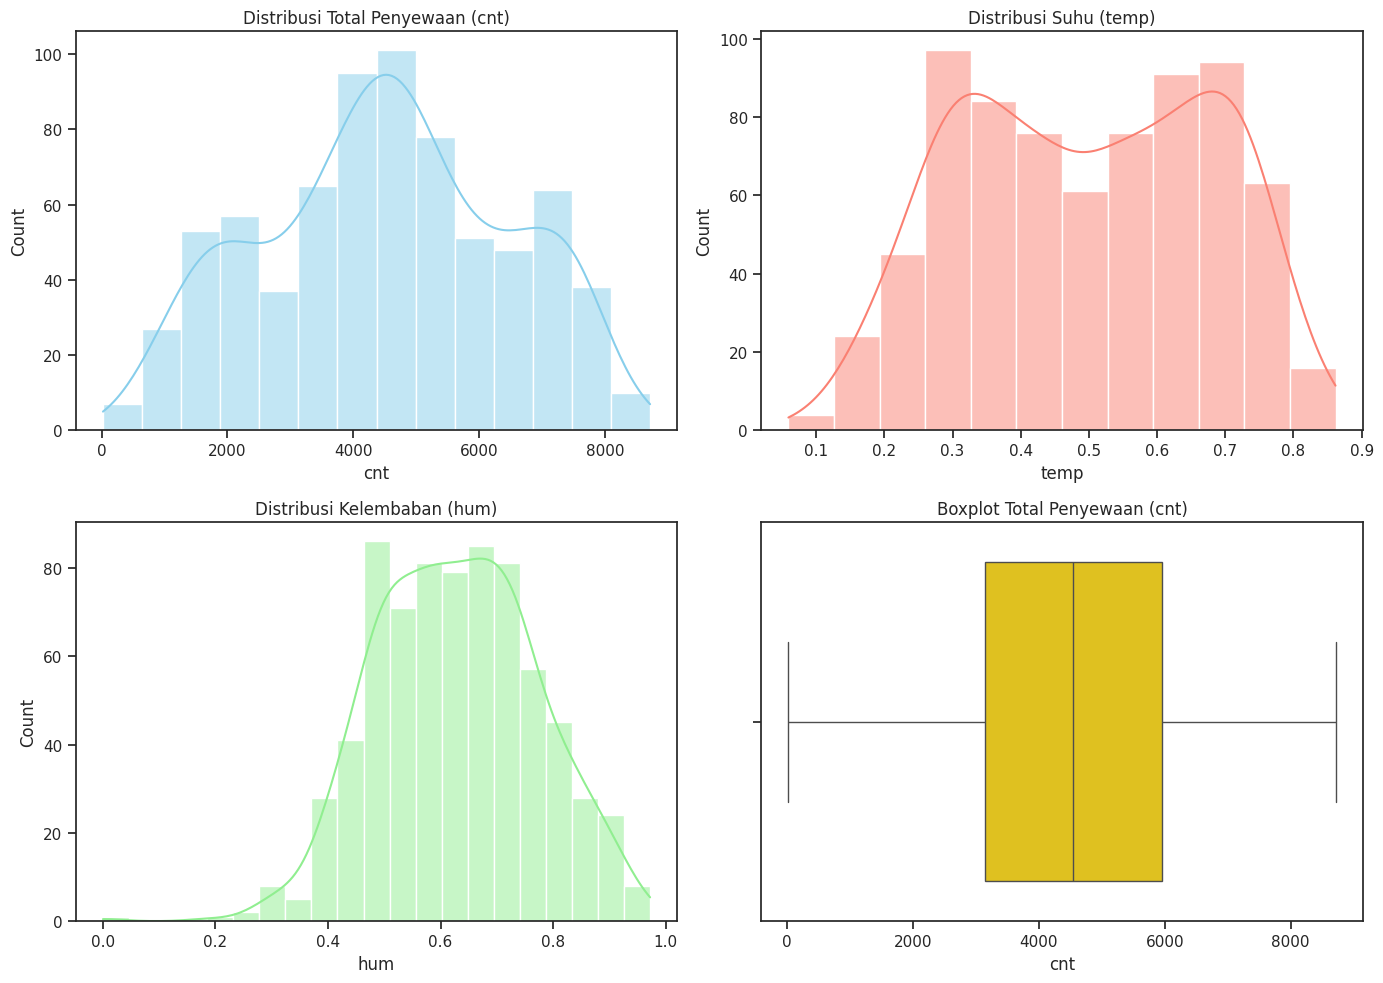

Analisis Bentuk Distribusi Total Penyewaan (cnt):
Skewness: -0.05 (Mendekati 0 = Distribusi cukup simetris)
Kurtosis: -0.81 (Nilai negatif = Distribusi lebih datar/platykurtic dari kurva normal)


In [10]:
# Menyiapkan canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram & KDE Plot untuk continuous variables
sns.histplot(day_df['cnt'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribusi Total Penyewaan (cnt)')

sns.histplot(day_df['temp'], kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Distribusi Suhu (temp)')

sns.histplot(day_df['hum'], kde=True, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Distribusi Kelembaban (hum)')

# Boxplot untuk mendeteksi Quartiles, Median, dan Outliers pada target variable
sns.boxplot(x=day_df['cnt'], ax=axes[1,1], color='gold')
axes[1,1].set_title('Boxplot Total Penyewaan (cnt)')

plt.tight_layout()
plt.show()

# Skewness dan Kurtosis Analysis
print("Analisis Bentuk Distribusi Total Penyewaan (cnt):")
print(f"Skewness: {day_df['cnt'].skew():.2f} (Mendekati 0 = Distribusi cukup simetris)")
print(f"Kurtosis: {day_df['cnt'].kurtosis():.2f} (Nilai negatif = Distribusi lebih datar/platykurtic dari kurva normal)")

**Insight EDA Univariate:**
* Distribusi data penyewaan (`cnt`) terlihat cukup simetris (skewness mendekati 0) namun puncaknya lebih datar dibandingkan kurva normal standar (*platykurtic*).
* Melalui Boxplot, tidak ditemukan *outlier* (pencilan data) yang ekstrem pada total penyewaan harian.

### 2. EDA Multivariate

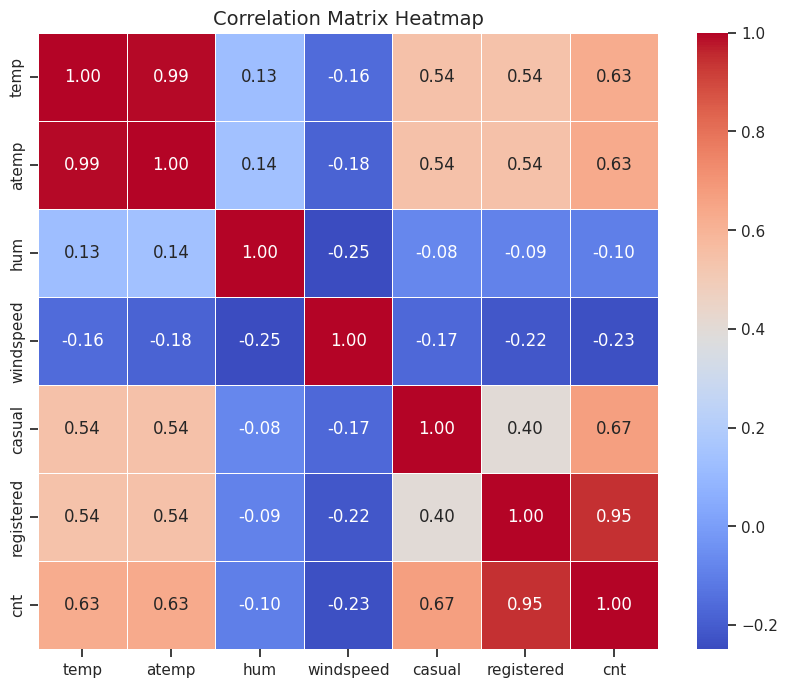

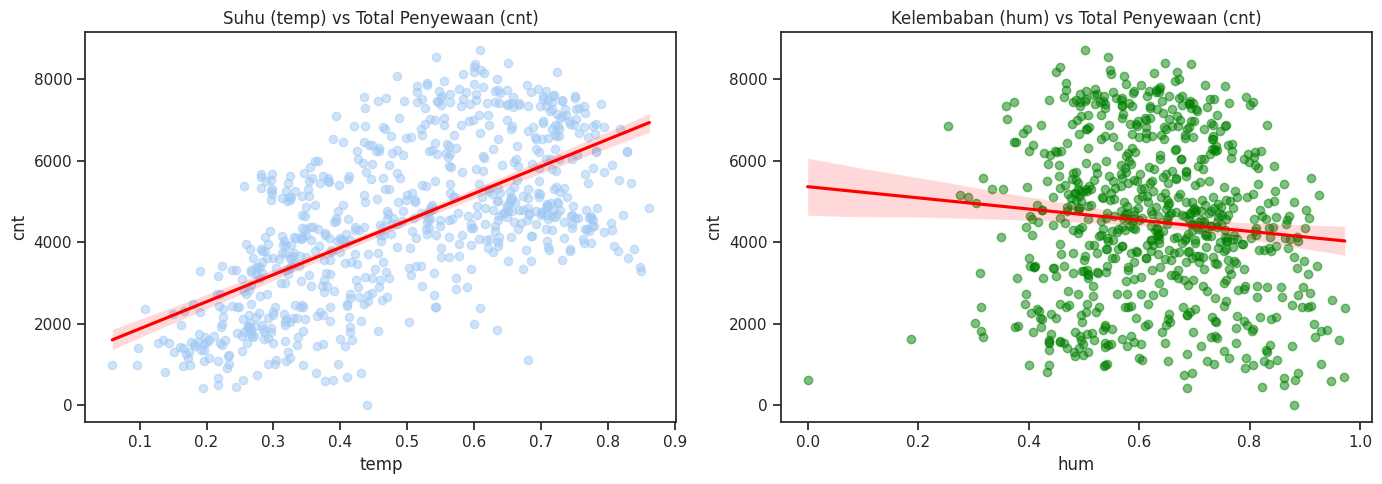

In [11]:
# Correlation Matrix Heatmap
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
plt.figure(figsize=(10, 8))
sns.heatmap(day_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()

# Scatter Plot dengan Regression Line (Bivariate relationship)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.regplot(x='temp', y='cnt', data=day_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Suhu (temp) vs Total Penyewaan (cnt)')

plt.subplot(1, 2, 2)
sns.regplot(x='hum', y='cnt', data=day_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, color='green')
plt.title('Kelembaban (hum) vs Total Penyewaan (cnt)')
plt.tight_layout()
plt.show()

**Insight EDA Multivariate:**
* *Heatmap* membuktikan ada korelasi positif yang sangat kuat (0.63) antara suhu (`temp`) dengan jumlah penyewaan (`cnt`). Semakin hangat, semakin banyak sepeda yang disewa.
* Sebaliknya, kelembaban (`hum`) dan kecepatan angin (`windspeed`) memiliki korelasi negatif yang mengindikasikan penurunan penyewaan saat cuaca memburuk.

### 3. EDA Numerikal


Detailed Percentiles Analysis untuk 'cnt':
5th Percentile: 1331
10th Percentile: 1746
25th Percentile: 3152
50th Percentile: 4548
75th Percentile: 5956
90th Percentile: 7290
95th Percentile: 7576


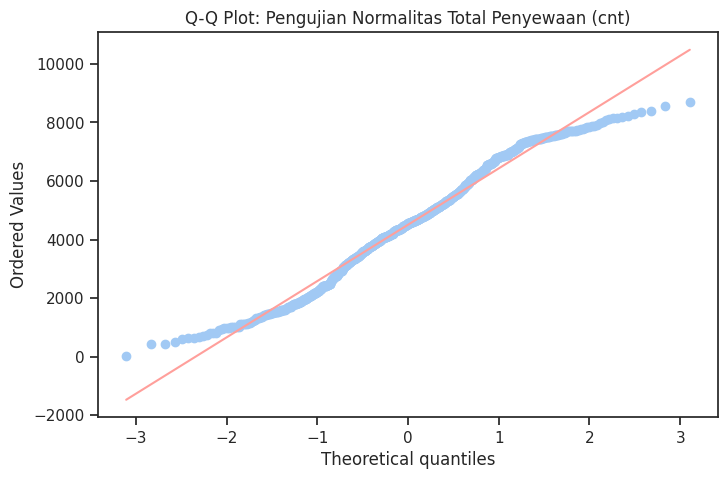


Variance & Standard Deviation per Musim:


,var,std,mean
season_label,,,
Fall,2131017.15,1459.80,5644.30
Spring,1959837.94,1399.94,2604.13
Summer,2876338.78,1695.98,4992.33
Winter,2888692.04,1699.62,4728.16


In [12]:
# Detailed Percentile Analysis
percentiles = [5, 10, 25, 50, 75, 90, 95]
percentile_values = np.percentile(day_df['cnt'], percentiles)
print("Detailed Percentiles Analysis untuk 'cnt':")
for p, v in zip(percentiles, percentile_values):
    print(f"{p}th Percentile: {v:.0f}")

# Normality Testing dengan Q-Q Plot
plt.figure(figsize=(8, 5))
stats.probplot(day_df['cnt'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Pengujian Normalitas Total Penyewaan (cnt)')
plt.show()

# Variance & Standard Deviation Analysis per Musim
var_std_season = day_df.groupby('season_label')['cnt'].agg(['var', 'std', 'mean']).round(2)
print("\nVariance & Standard Deviation per Musim:")
display(var_std_season)

**Insight EDA Numerikal:**
* Berdasarkan Q-Q Plot, titik-titik data sebagian besar mengikuti garis merah, namun sedikit melenceng di ujung atas dan bawah, mengonfirmasi bahwa data tidak berdistribusi normal sempurna.
* Musim gugur (*Fall*) memiliki rata-rata penyewaan tertinggi sekaligus variabilitas data (*variance*) yang paling tinggi.


### 4. EDA Kategorikal

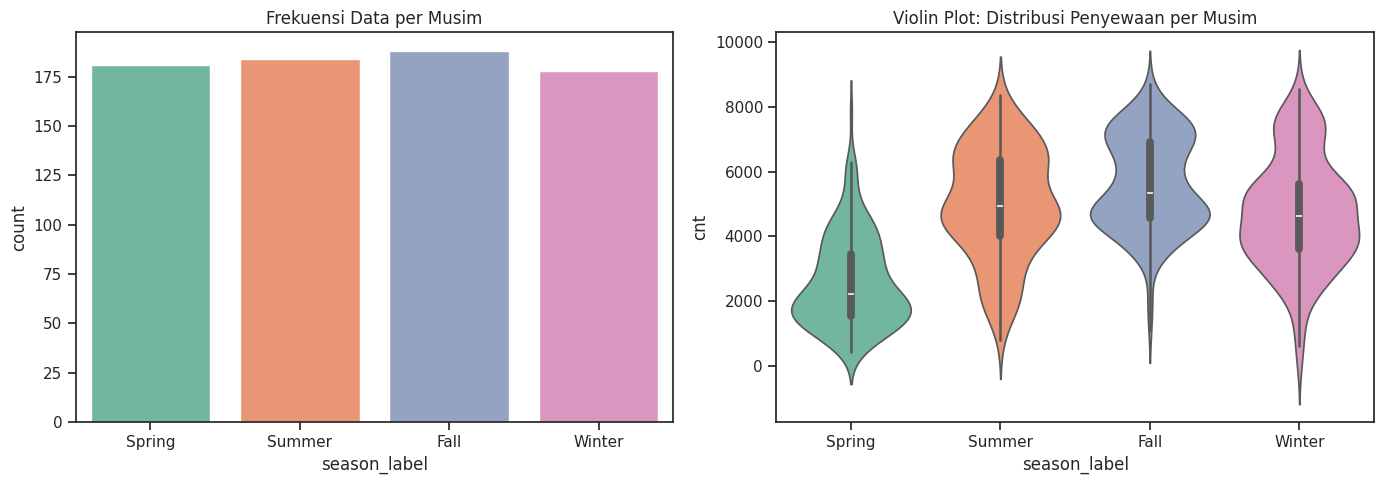

Hasil Uji Kruskal-Wallis untuk Musim vs Total Penyewaan:
P-Value: 4.110755793069794e-54
Kesimpulan: Terdapat perbedaan median yang SIGNIFIKAN pada total penyewaan antar musim.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seaborn Countplot untuk frekuensi kategori
sns.countplot(x='season_label', data=day_df, ax=axes[0], palette='Set2')
axes[0].set_title('Frekuensi Data per Musim')

# Violin Plot untuk distribusi 'cnt' across categories
sns.violinplot(x='season_label', y='cnt', data=day_df, ax=axes[1], palette='Set2')
axes[1].set_title('Violin Plot: Distribusi Penyewaan per Musim')

plt.tight_layout()
plt.show()

# Statistical Testing (Kruskal-Wallis)
# Menggunakan Kruskal karena Q-Q plot sebelumnya menunjukkan distribusi cnt tidak 100% normal
groups = [group['cnt'].values for name, group in day_df.groupby('season_label')]
stat, p_value = stats.kruskal(*groups)

print("Hasil Uji Kruskal-Wallis untuk Musim vs Total Penyewaan:")
print(f"P-Value: {p_value}")
if p_value < 0.05:
    print("Kesimpulan: Terdapat perbedaan median yang SIGNIFIKAN pada total penyewaan antar musim.")
else:
    print("Kesimpulan: TIDAK ada perbedaan median yang signifikan antar musim.")

**Insight EDA Kategorikal:**
* Frekuensi data pengamatan tiap musim terdistribusi merata (masing-masing sekitar 180 hari).
* Hasil uji statistik *Kruskal-Wallis* memastikan secara saintifik (*P-Value* mendekati 0.0) bahwa perubahan musim benar-benar memberikan perbedaan signifikan terhadap minat penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap total penyewaan sepeda selama tahun 2011-2012?

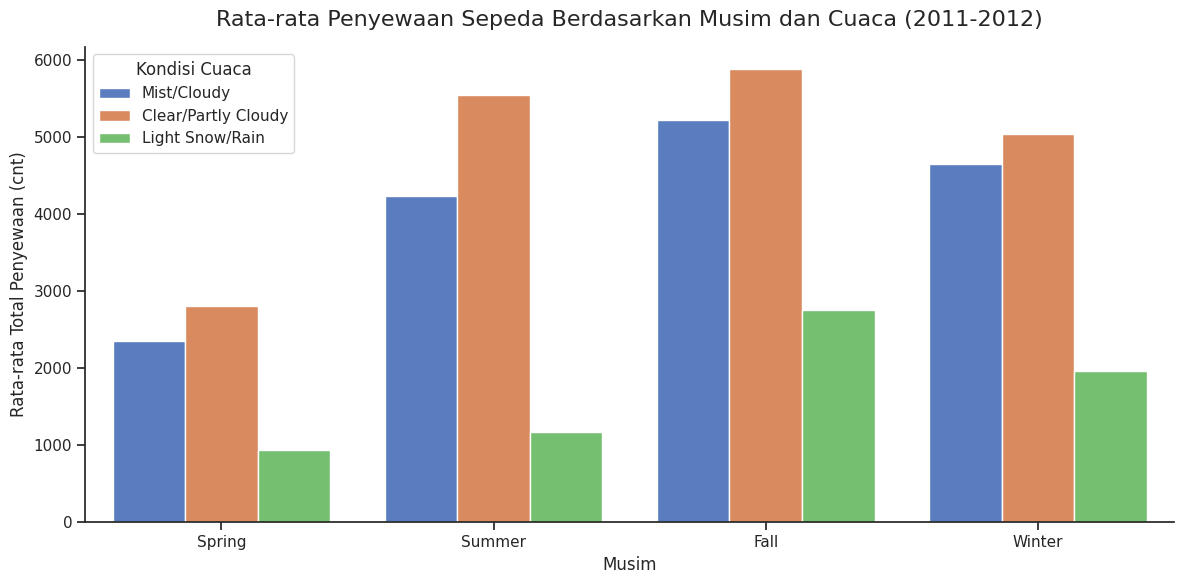

In [14]:
plt.figure(figsize=(12, 6))

# Menggunakan barplot
ax = sns.barplot(
    x='season_label',
    y='cnt',
    hue='weather_label',
    data=day_df,
    errorbar=None,
    palette='muted'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim dan Cuaca (2011-2012)', fontsize=16, pad=15)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan (cnt)', fontsize=12)
plt.legend(title='Kondisi Cuaca')
sns.despine()
ax.set_ylim(ymin=0)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari antara hari kerja dan hari libur dalam keseluruhan periode observasi?

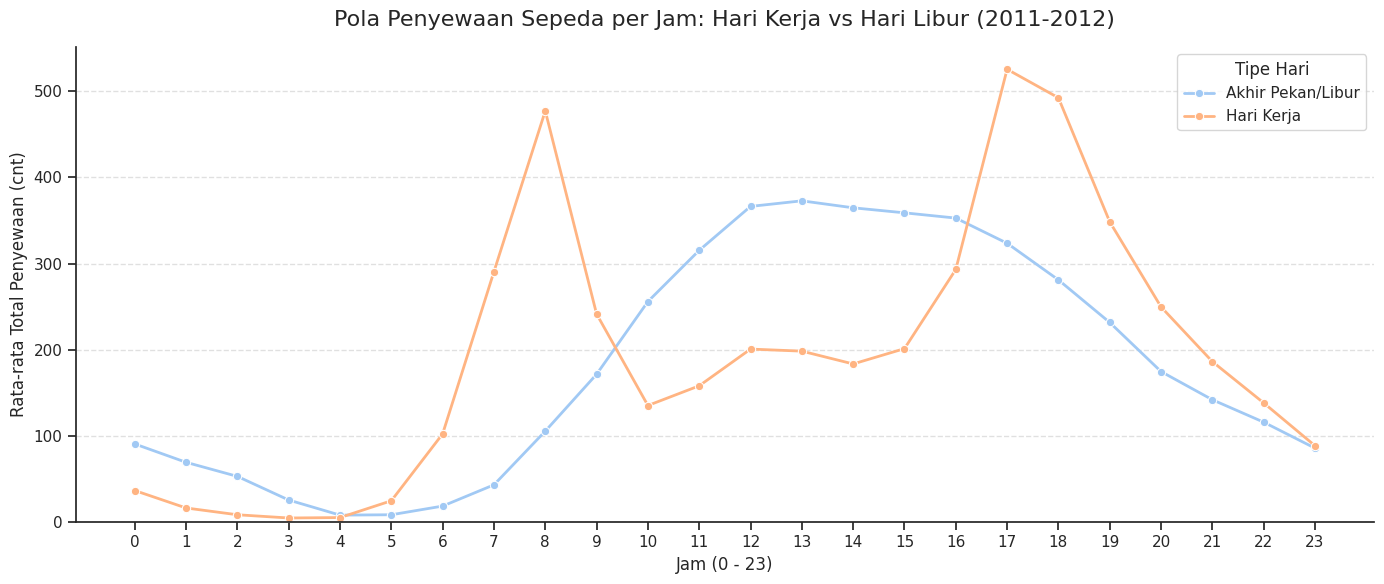

In [15]:
plt.figure(figsize=(14, 6))

# Membuat line chart
ax2 = sns.lineplot(
    x='hr',
    y='cnt',
    hue='day_type',
    data=hour_df,
    marker='o',
    errorbar=None,
    linewidth=2
)

plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur (2011-2012)', fontsize=16, pad=15)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan (cnt)', fontsize=12)
plt.xticks(np.arange(0, 24, 1))
plt.legend(title='Tipe Hari')
plt.grid(axis='y', linestyle='--', alpha=0.6)

sns.despine()
ax2.set_ylim(ymin=0)

plt.tight_layout()
plt.show()

**Insight Visualisasi:**
* **Visualisasi 1:** Cuaca cerah mendominasi tingginya angka penyewaan di seluruh musim. Cuaca ekstrem (hujan lebat/salju) mematikan minat penyewaan hampir secara keseluruhan. Cuaca, curah hujan, dan musim memang sangat mempengaruhi perilaku rental.
* **Visualisasi 2:** Terlihat lonjakan ekstrem (*bimodal peak*) pada pukul 08:00 dan 17:00 di hari kerja, mengindikasikan sepeda digunakan untuk transportasi *commuting* kantoran. Di akhir pekan, polanya memusat membentuk kurva lonceng di siang hari antara jam 10:00 hingga 16:00.

## Analisis Lanjutan (Opsional): Clustering/Binning Waktu Dalam Sehari

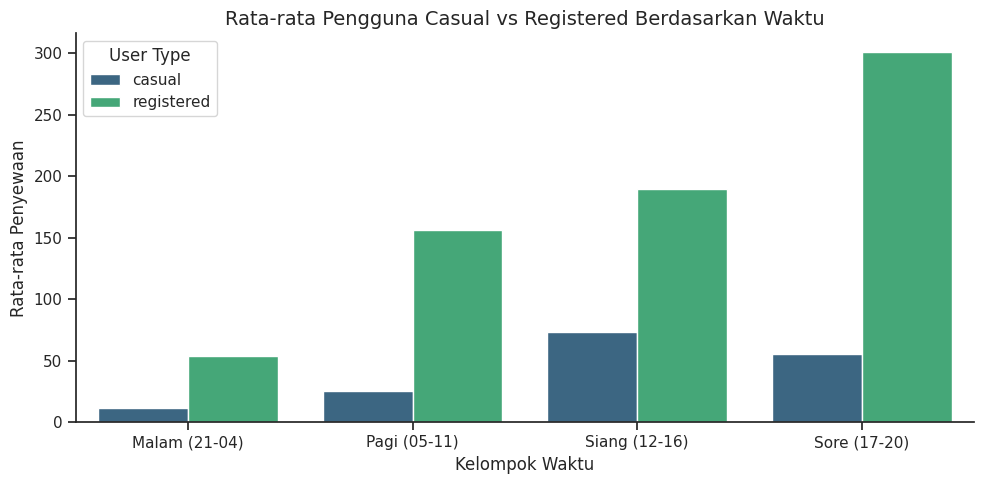

In [16]:
# Mendefinisikan fungsi binning waktu
def categorize_time_of_day(hour):
    if 5 <= hour <= 11:
        return 'Pagi (05-11)'
    elif 12 <= hour <= 16:
        return 'Siang (12-16)'
    elif 17 <= hour <= 20:
        return 'Sore (17-20)'
    else:
        return 'Malam (21-04)'

# Menerapkan fungsi ke dataset
hour_df['time_group'] = hour_df['hr'].apply(categorize_time_of_day)

# Agregasi data pengguna casual vs registered berdasarkan kelompok waktu
time_clustering = hour_df.groupby('time_group')[['casual', 'registered']].mean().reset_index()

# Visualisasi hasil grouping
time_clustering_melted = time_clustering.melt(id_vars='time_group', var_name='User Type', value_name='Average Rentals')

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(x='time_group', y='Average Rentals', hue='User Type', data=time_clustering_melted, palette='viridis')
plt.title('Rata-rata Pengguna Casual vs Registered Berdasarkan Waktu', fontsize=14)
plt.xlabel('Kelompok Waktu', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

# Optimasi Integritas Visual
sns.despine()
ax3.set_ylim(ymin=0)
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**
Melalui binning berbasis aturan waktu operasional, dapat disimpulkan bahwa kelompok pengguna *registered* sangat mendominasi penyewaan secara absolut, khususnya pada sesi Sore (17:00-20:00) saat jam pulang kerja. Pengguna *casual* paling aktif di waktu Siang (12:00-16:00), kemungkinan besar merupakan turis atau penyewa rekreasi santai.

## Conclusion

- **Conclution Pertanyaan 1:** Selama observasi tahun 2011-2012, terbukti secara visual dan uji statistik bahwa kondisi iklim berkorelasi kuat dengan operasional sistem. Pengguna paling banyak menyewa sepeda di musim gugur (*Fall*). Cuaca cerah mendominasi angka sewa tertinggi, sementara cuaca hujan badai (*Heavy Rain/Snow*) membuat angka penyewaan anjlok drastis di semua musim. Suhu (`temp`) merupakan faktor pendorong paling kuat.
- **Conclution Pertanyaan 2:** Selama periode observasi 2011-2012, perilaku penyewaan sangat dipengaruhi oleh hari. Pada hari kerja, terdapat lonjakan tajam (bimodal peak) pada pukul 08:00 dan 17:00, mengonfirmasi penggunaan sepeda sebagai alat komuter/transportasi bekerja. Di akhir pekan, pola komuter hilang, digantikan oleh peningkatan bertahap yang membentuk kurva lonceng mulai pukul 10:00 hingga 16:00, menandakan penggunaan rekreasional di siang hari.

In [17]:
# Menggabungkan dataset hour_df dan day_df menjadi all_df
# Kita menggunakan left join berdasarkan kolom tanggal 'dteday'
# Suffixes digunakan untuk membedakan nama kolom yang sama antara kedua dataset (contoh: cnt_hour dan cnt_day)
all_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    left_on="dteday",
    right_on="dteday",
    suffixes=("_hour", "_day")
)

# Menyimpan dataframe all_df menjadi file main_data.csv
all_df.to_csv("main_data.csv", index=False)

print("Berhasil! File main_data.csv telah dibuat.")

Berhasil! File main_data.csv telah dibuat.
